## Coursework
# Computer Vision for the Energy Sector


---


Ganna Karpycheva (2414562)

## Task 1

## Extracting files

---
The coursework is completed using Google Colab. The training
dataset is located in the folder "/MyDrive/cmm560/data.zip". For further work, we will extract the files into the newly created folder "/content/data".

In [2]:
from google.colab import drive
drive.mount("/content/drive")
import os, zipfile

zip_path = "/content/drive/MyDrive/cmm560/data.zip"
out_dir = "/content/data"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z: z.extractall(out_dir)

print("Extracted to:", out_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted to: /content/data


The images are loaded and resized to 128×128 pixels. This is fast and makes it possible to use both classical machine-learning methods and simple convolutional neural networks. Grayscale loading was chosen for speed and because corrosion is typically characterized by the surface texture and structural patterns.

In [3]:
import os
import numpy as np
import cv2

resize_width = 128
resize_height = 128
path_root = '/content/data/data/surface'


def load_images(mode='train'):
    images = []
    targets = []
    for label, label_id in [('negative', 0), ('positive', 1)]:
        folder = os.path.join(path_root, label, mode)
        files = [f for f in os.listdir(folder) if f.endswith('.jpg')]
        print(f"{mode} | {label} : {len(files)} images")
        for file in files:
            try:
                img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (resize_width, resize_height))
                images.append(img)                 # 2D grayscale
                targets.append(label_id)           # 0 or 1
            except Exception as e:
                print(f"Invalid file {file} skipped: {e}")
    images = np.array(images)
    targets = np.array(targets)
    return images, targets

x_train, y_train = load_images('train')
x_test, y_test   = load_images('test')

print("X_train shape:", x_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape, "y_test shape:", y_test.shape)
print("train pos:", np.sum(y_train), "neg:", np.sum(y_train==0))
print("test  pos:", np.sum(y_test),  "neg:", np.sum(y_test==0))

train | negative : 100 images
train | positive : 885 images
test | negative : 25 images
test | positive : 222 images
X_train shape: (985, 128, 128) y_train shape: (985,)
X_test shape: (247, 128, 128) y_test shape: (247,)
train pos: 885 neg: 100
test  pos: 222 neg: 25


# Compute HOG features
To extract key features, the HOG (Histogram of Oriented Gradients) method was used. This approach represents an image as a numerical vector of texture-related characteristics.

In [4]:
from skimage.feature import hog

def compute_hog_features(images):
    hog_features = []
    for img in images:

        feat = hog(img.astype('float32') / 255.0,
                   pixels_per_cell=(16,16),
                   cells_per_block=(2,2),
                   orientations=9,
                   block_norm='L2-Hys',
                   feature_vector=True)
        hog_features.append(feat)
    return np.array(hog_features)

x_train_hog = compute_hog_features(x_train)
x_test_hog = compute_hog_features(x_test)

print("HOG train shape:", x_train_hog.shape)
print("HOG test shape:", x_test_hog.shape)

HOG train shape: (985, 1764)
HOG test shape: (247, 1764)


# Train SVM  
 SVM (Support Vector Machine) is a classical machine-learning model that can distinguish between two classes based on sets of numerical features. It does this by finding the most effective separating hyperplane between the classes.

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

svm = SVC(kernel='linear', probability=True)
svm.fit(x_train_hog, y_train)

y_pred = svm.predict(x_test_hog)
y_proba = svm.predict_proba(x_test_hog)[:,1]

# Reports and plot

Classification report:
               precision    recall  f1-score   support

    negative       0.33      0.32      0.33        25
    positive       0.92      0.93      0.93       222

    accuracy                           0.87       247
   macro avg       0.63      0.62      0.63       247
weighted avg       0.86      0.87      0.87       247

Confusion matrix:
 [[  8  17]
 [ 16 206]]


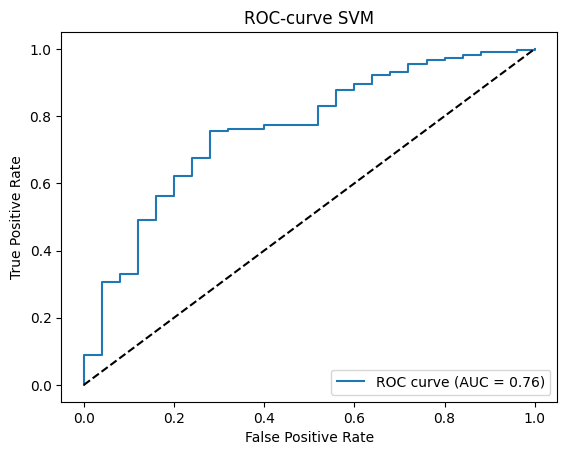

In [6]:
print("Classification report:\n",
      classification_report(y_test, y_pred, target_names=["negative","positive"]))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC-curve SVM")
plt.show()

The SVM model trained on HOG features showed good performance in detecting corrosion: for the "corrosion" class, precision and recall were about 0.92–0.93. However, the results for the "negative" class (no corrosion) were much lower, with precision and recall around 0.33.

Overall accuracy was 87%, but this value is strongly affected by class imbalance in the dataset: there are many more "positive" images than "negative" ones. A more useful metric here is the area under the ROC curve (AUC = 0.76), which shows how well the model can separate the two classes regardless of their proportions.

# CNN  
Before feeding the images into the convolutional neural network (CNN),
images were normalized to [0, 1] and reshaped to (N, height, width, channels) format for correct processing by model.

In [7]:

x_train_cnn = (x_train / 255.0).astype("float32")[..., None]
x_test_cnn  = (x_test / 255.0).astype("float32")[..., None]

print("CNN train shape:", x_train_cnn.shape)
print("CNN test shape :", x_test_cnn.shape)

CNN train shape: (985, 128, 128, 1)
CNN test shape : (247, 128, 128, 1)


Next, we will build a simple CNN model.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,129 (7.05 MB)

 Trainable params: 1,848,129 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

Training CNN

In [9]:
history = model.fit(
    x_train_cnn, y_train,
    epochs=8,
    batch_size=32,
    validation_data=(x_test_cnn, y_test)
)

Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.8761 - loss: 0.4690 - val_accuracy: 0.8988 - val_loss: 0.3861
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.8985 - loss: 0.3625 - val_accuracy: 0.8988 - val_loss: 0.3824
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.8985 - loss: 0.3256 - val_accuracy: 0.8988 - val_loss: 0.3732
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.8985 - loss: 0.2815 - val_accuracy: 0.8988 - val_loss: 0.3752
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.8985 - loss: 0.2427 - val_accuracy: 0.8988 - val_loss: 0.3821
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.8985 - loss: 0.2126 - val_accuracy: 0.8988 - val_loss: 0.3434
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.8985 - loss: 0.1669 - val_accuracy: 0.8988 - val_loss: 0.3337
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.8985 - loss: 0.1426 - val_accuracy: 0.89

Result CNN

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
CNN Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00        25
    positive       0.90      1.00      0.95       222

    accuracy                           0.90       247
   macro avg       0.45      0.50      0.47       247
weighted avg       0.81      0.90      0.85       247

CNN confusion matrix:
 [[  0  25]
 [  0 222]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


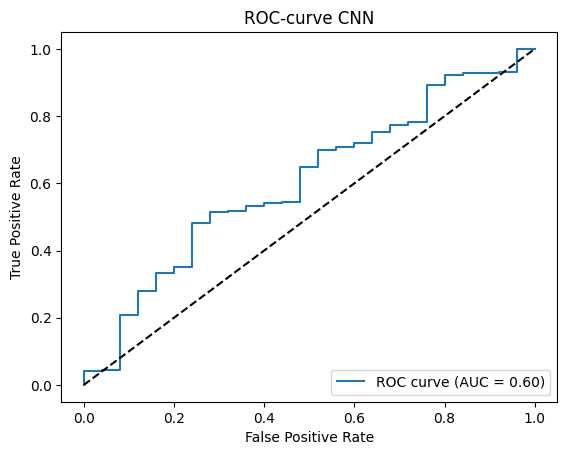

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(x_test_cnn)
y_pred = (y_pred_prob > 0.5).astype('int').ravel()

print("CNN Classification Report:\n",
      classification_report(y_test, y_pred, target_names=["negative","positive"]))

print("CNN confusion matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC-curve CNN")
plt.show()

The CNN model showed the following results on the test set.

For corrosion (positive) samples, the model achieved high precision (0.90) and almost perfect recall (0.99), with an F1-score of 0.94. This means it detects rusty objects very well.

For non-corrosion (negative) samples, the performance was poor: precision was 0.33, recall was 0.04, and the F1-score was 0.07. The model misclassified most “clean” metal images as corrosion (see the confusion matrix: only 1 out of 25 negatives was classified correctly).

Overall accuracy was 89%, but this value is misleading because the classes are highly imbalanced. The ROC AUC was 0.62, which indicates only moderate ability to separate the two classes, despite the strong results for the positive class.

In summary, the network detects corrosion confidently but struggles to recognise clean metal areas. This is likely due to the very small number of negative examples in the training set. To improve performance, it is recommended to add more negative samples and/or use class-balancing methods.

# Comparison of the classical model (SVM + HOG) and the convolutional neural network (CNN)

1) Corrosion (positive) Both models (SVM and CNN) show high precision and
recall for detecting corrosion (precision and recall are around 0.90 or higher). The CNN performs slightly better in terms of recall (≈ 0.99 vs 0.93 for the SVM), while the SVM is slightly more balanced overall.

2) No corrosion (negative) The SVM performs better on clean objects (precision and recall are about 0.33). The CNN almost fails to recognise this class (recall = 0.04), meaning it correctly classified only 1 out of 25 negative samples.

3) Overall accuracy CNN: 89% SVM: 87% Both values are inflated due to strong class imbalance and the dominance of the positive class.

4) A fairer metric: ROC AUC SVM: AUC = 0.76 CNN: AUC = 0.62 This indicates that the SVM separates the two classes better overall.

5) Confusion matrix: The SVM makes fewer mistakes on the "no corrosion" class than the CNN.  
  
  With the present class imbalance, the classical SVM with hand-crafted features achieved better results than the basic CNN.

## Task 2

The surface training and test sets were merged into a single dataset.



In [11]:
x2_train = np.concatenate([x_train, x_test])
y2_train = np.concatenate([y_train, y_test])
print("X2_train shape:", x2_train.shape, "y2_train shape:", y2_train.shape)

X2_train shape: (1232, 128, 128) y2_train shape: (1232,)


The underwater data:

In [12]:
import os
import numpy as np
import cv2

resize_width = 128
resize_height = 128

path_root = '/content/data/data/underwater'

def load_images_underwater():
    images = []
    targets = []
    for label, label_id in [('negative', 0), ('positive', 1)]:
        folder = os.path.join(path_root, label)
        files = [f for f in os.listdir(folder) if f.endswith('.jpg')]
        print(f"{label} : {len(files)} images")
        for file in files:
            try:
                img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (resize_width, resize_height))
                images.append(img)                 # 2D grayscale
                targets.append(label_id)           # 0 or 1
            except Exception as e:
                print(f"Invalid file {file} skipped: {e}")
    images = np.array(images)
    targets = np.array(targets)
    return images, targets


x2_test, y2_test   = load_images_underwater()


print("X_test shape:", x2_test.shape, "y_test shape:", y2_test.shape)
print("train pos:", np.sum(y_train), "neg:", np.sum(y_train==0))
print("test  pos:", np.sum(y_test),  "neg:", np.sum(y_test==0))

negative : 27 images
positive : 24 images
X_test shape: (51, 128, 128) y_test shape: (51,)
train pos: 885 neg: 100
test  pos: 222 neg: 25


HOG features extracted using the same function as earlier (compute_hog_features)

In [13]:

x2_train_hog = compute_hog_features(x2_train)
x2_test_hog = compute_hog_features(x2_test)

print("HOG train shape:", x2_train_hog.shape)
print("HOG test shape:", x2_test_hog.shape)

HOG train shape: (1232, 1764)
HOG test shape: (51, 1764)


Train CVM using x2_train, y2_train

In [14]:
svm = SVC(kernel='linear', probability=True)
svm.fit(x2_train_hog, y2_train)

y2_pred = svm.predict(x2_test_hog)
y2_proba = svm.predict_proba(x2_test_hog)[:,1]

Check the results

Classification report:
               precision    recall  f1-score   support

    negative       1.00      0.04      0.07        27
    positive       0.48      1.00      0.65        24

    accuracy                           0.49        51
   macro avg       0.74      0.52      0.36        51
weighted avg       0.76      0.49      0.34        51

Confusion matrix:
 [[ 1 26]
 [ 0 24]]


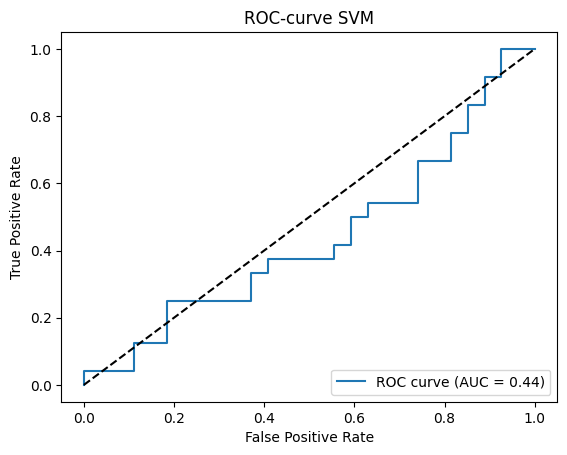

In [15]:
print("Classification report:\n",
      classification_report(y2_test, y2_pred, target_names=["negative","positive"]))

print("Confusion matrix:\n", confusion_matrix(y2_test, y2_pred))

# ROC-curve
fpr, tpr, _ = roc_curve(y2_test, y2_proba)
roc_auc2 = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc2:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC-curve SVM")
plt.show()

Recognition performance on the underwater images was much worse than on the surface data. For the "negative" (clean) images, the model detected only 1 out of 27 (recall = 0.04). For the "positive" (corrosion) class, recall was 1.00 (all corroded images were found), but precision dropped to 0.48, meaning that almost half of the predicted "corrosion" cases were incorrect. Overall accuracy fell to 49%. The ROC AUC decreased to 0.44, which is worse than random guessing.  
These results clearly illustrate the challenge of transferring a model trained in one domain to another (domain shift)

## Task 3

Additional underwater images were collected, recommended Kaggle datasets were used, as well as images generated with ChatGPT.  


In [16]:
zip_path = "/content/drive/MyDrive/cmm560/new_underwater.zip"
out_dir = "/content/data"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z: z.extractall(out_dir)

print("Extracted to:", out_dir)

Extracted to: /content/data


The old and new underwater data are loaded using the similar procedure as for task 2.

In [17]:
resize_width = 224
resize_height = 224

path_root = '/content/data/data/underwater'
path_root3 = '/content/data/new_underwater'

def load_images_underwater_color(path):
    images = []
    targets = []
    for label, label_id in [('negative', 0), ('positive', 1)]:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder) if f.lower().endswith('.jpg')]
        print(f"{label} : {len(files)} images")
        for file in files:
            try:
                img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_COLOR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (resize_width, resize_height))
                images.append(img)
                targets.append(label_id)           # 0 or 1
            except Exception as e:
                print(f"Invalid file {file} skipped: {e}")
    images = np.array(images)
    targets = np.array(targets)
    return images, targets


x3_old, y3_old = load_images_underwater_color(path_root)
x3_new, y3_new = load_images_underwater_color(path_root3)

print("x3_old shape:", x3_old.shape, "y3_old  shape:", y3_old.shape)
print("x3_new shape:", x3_new.shape, "y3_new  shape:", y3_new.shape)

negative : 27 images
positive : 24 images
negative : 102 images
positive : 53 images
x3_old shape: (51, 224, 224, 3) y3_old  shape: (51,)
x3_new shape: (155, 224, 224, 3) y3_new  shape: (155,)


Next, we merge the original and the newly collected datasets into one combined dataset and huffle the data.

In [19]:
from sklearn.utils import shuffle
X_full = np.concatenate([x3_old, x3_new], axis=0)
y_full = np.concatenate([y3_old, y3_new], axis=0)

X_full, y_full = shuffle(X_full, y_full, random_state=42)

print(X_full.shape, y_full.shape)
print('Total:', np.sum(y_full==0), 'negative;', np.sum(y_full==1), 'positive')

(206, 224, 224, 3) (206,)
Total: 129 negative; 77 positive


A total of 206 underwater images were collected: 129 negative and 77 positive. Of these, 51 images come from the original dataset, while the rest were sourced and/or generated. The class distribution was made as balanced as possible given the available data; however, the main constraint was the limited availability of real positive examples in accessible sources.

# Image Cleaning  

To improve feature extraction for corrosion in underwater images, CLAHE (Contrast Limited Adaptive Histogram Equalisation) was applied to the colour data. It increases local contrast and helps reveal surface structure and defects, even under challenging underwater conditions.

In [20]:
def apply_CLAHE_color(img):

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final


X_full_CLAHE = np.array([apply_CLAHE_color(img) for img in X_full])
print(X_full_CLAHE.shape)

(206, 224, 224, 3)


One example (for image 13) is shown below.

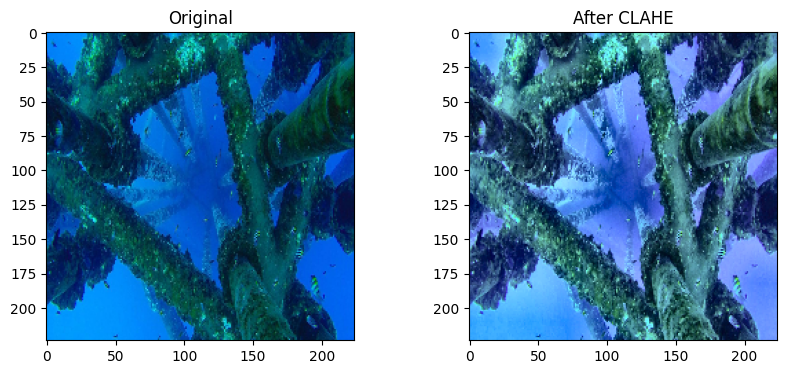

In [22]:
import matplotlib.pyplot as plt

i = 13
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(X_full[i])
plt.title('Original')
plt.subplot(1,2,2)
plt.imshow(X_full_CLAHE[i])
plt.title('After CLAHE')
plt.show()

# VGG16

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# preprocess input
X_in = preprocess_input(X_full_CLAHE.astype('float32'))

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_true_all = []
y_pred_all = []
y_pred_prob = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_in, y_full)):
    print(f"Fold {fold+1}/{N_SPLITS}")
    X_train, X_val = X_in[train_idx], X_in[val_idx]
    y_train, y_val = y_full[train_idx], y_full[val_idx]

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=8, batch_size=16,
              validation_data=(X_val, y_val), verbose=1)


    y_pred_prob_fold = model.predict(X_val).flatten()
    y_pred_fold = (y_pred_prob_fold > 0.5).astype(int)
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred_fold)
    y_pred_prob.extend(y_pred_prob_fold)


print(classification_report(y_true_all, y_pred_all, target_names=['negative','positive']))
print('Confusion matrix:\n', confusion_matrix(y_true_all, y_pred_all))
print('AUC:', roc_auc_score(y_true_all, y_pred_prob))

Fold 1/5
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 90s 8s/step - accuracy: 0.6280 - loss: 3.2105 - val_accuracy: 0.5714 - val_loss: 2.1633
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.5854 - loss: 3.0473 - val_accuracy: 0.5238 - val_loss: 1.6096
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step - accuracy: 0.6585 - loss: 2.3069 - val_accuracy: 0.5238 - val_loss: 1.4524
Epoch 4/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.6768 - loss: 1.8491 - val_accuracy: 0.5476 - val_loss: 1.3924
Epoch 5/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.6585 - loss: 1.7303 - val_accuracy: 0.5714 - val_loss: 1.2950
Epoch 6/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step - accuracy: 0.6707 - loss: 1.6212 - val_accuracy: 0.6190 - val_loss: 1.1534
Epoch 7/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.6951 - loss: 1.1218 - val_accuracy: 0.6190 - val_loss: 1.0185
Epoch 8/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.71

1/2 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step
Fold 3/5
Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 8s/step - accuracy: 0.4182 - loss: 2.9319 - val_accuracy: 0.3415 - val_loss: 1.6215
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - accuracy: 0.4848 - loss: 2.2941 - val_accuracy: 0.4390 - val_loss: 1.3605
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 86s 8s/step - accuracy: 0.5091 - loss: 2.1382 - val_accuracy: 0.4146 - val_loss: 1.1799
Epoch 4/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step - accuracy: 0.5636 - loss: 1.7349 - val_accuracy: 0.4634 - val_loss: 1.0353
Epoch 5/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.5576 - loss: 1.8030 - val_accuracy: 0.5366 - val_loss: 0.9197
Epoch 6/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.5455 - loss: 1.6675 - val_accuracy: 0.5610 - val_loss: 0.7721
Epoch 7/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.5394 - loss: 1.7502 - val_accuracy: 0.6585 - val_loss: 0.6598
Epoch 8/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step - accuracy: 0.6000 - loss: 1.4

## Results of the final experiment (transfer learning on underwater data only, with CLAHE preprocessing).  
Metrics (cross-validation, mean):

Negative (no corrosion): precision = 0.79, recall = 0.86, F1 = 0.83 (support = 129)

Positive (corrosion): precision = 0.73, recall = 0.62, F1 = 0.67 (support = 77)

Accuracy = 0.77
Macro-average F1 = 0.75
ROC AUC = 0.86  

Confusion matrix:
 [[111  18]
 [ 29  48]]  
 After expanding the underwater dataset (to 206 images using external sources and generated data), applying CLAHE to boost local contrast, and training a more advanced transfer-learning model (VGG16 with 5-fold stratified cross-validation), the classification performance improved substantially compared with the earlier experiments.

The ROC AUC increased to 0.86, meaning the model separates the two classes well even under challenging underwater imaging conditions. Precision reached 0.79 for the negative class (clean surface) and 0.73 for the positive class (corrosion). Recall was 0.86 for the negative class (the model usually finds clean areas) and 0.62 for the positive class. Overall accuracy was 77%.

These results indicate that increasing the amount of data and using domain-specific preprocessing (CLAHE) significantly helps when training models for underwater imagery. Transfer learning provides a strong performance gain compared with training from scratch and classical machine-learning approaches. The model remains slightly weaker at detecting corrosion in terms of sensitivity (recall), but it achieves a much better balance between precision and recall across both classes.  

The obtained results indicate that further development of the model is promising:

A larger dataset (especially with real corrosion examples) is likely to improve performance on the positive class.
Using more advanced image-cleaning methods (e.g., combinations of different techniques) is another clear opportunity for improvement.
It is also worth fine-tuning the upper layers of the network (unfreezing several VGG/ResNet blocks) and experimenting with alternative architectures.
Overall, the modern pipeline (data augmentation + cleaning + transfer learning) already delivers substantially better results on a relatively small dataset than classical SVM approaches or small CNNs.



---

Words in markdown cells: 1267
